# Plot power curves for all 25 turbines

In [1]:
import itertools

import matplotlib.pyplot as plt

import pandas as pd

In [2]:
# configure plot styles
plt.style.use("seaborn-colorblind")
plt.rcParams["font.family"] = "Source Sans Pro"
plt.rcParams["figure.dpi"] = 96
plt.rcParams["axes.grid"] = False
plt.rcParams["figure.titleweight"] = "semibold"
plt.rcParams["axes.titleweight"] = "semibold"
plt.rcParams["figure.titlesize"] = "13"
plt.rcParams["axes.titlesize"] = "12"
plt.rcParams["axes.labelsize"] = "10"

In [4]:
# create dataframe from CSV
data = pd.read_csv(
    "data/processed/SCADA_timeseries.csv", skip_blank_lines=True
)

In [4]:
# create pivot table (new dataframe)
power = pd.pivot_table(
    data, index=["ws_av"], columns=["turbine"], values=["ap_av"]
)

In [5]:
# removing pivot table values name from heading
power.columns = power.columns.droplevel(0)

In [6]:
# rename index (x-axis title)
power.index.name = "Wind speed (m/s)"

In [7]:
power

turbine,1,2,3,4,5,6,7,8,9,10,...,16,17,18,19,20,21,22,23,24,25
Wind speed (m/s),,,,,,,,,,,,,,,,,,,,,
0.000000,0.0,0.0,0.0,0.0,0.0,0.050226,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.000007,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0.000007,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0.000007,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0.000007,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36.467920,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
36.558680,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
37.271650,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
# get coordinates of each subplot
layout = list(range(0, 5))
coord = list(itertools.product(layout, layout))

# list of column headers (i.e. turbines 1 to 25)
cols = list(power)

## Standard power curves

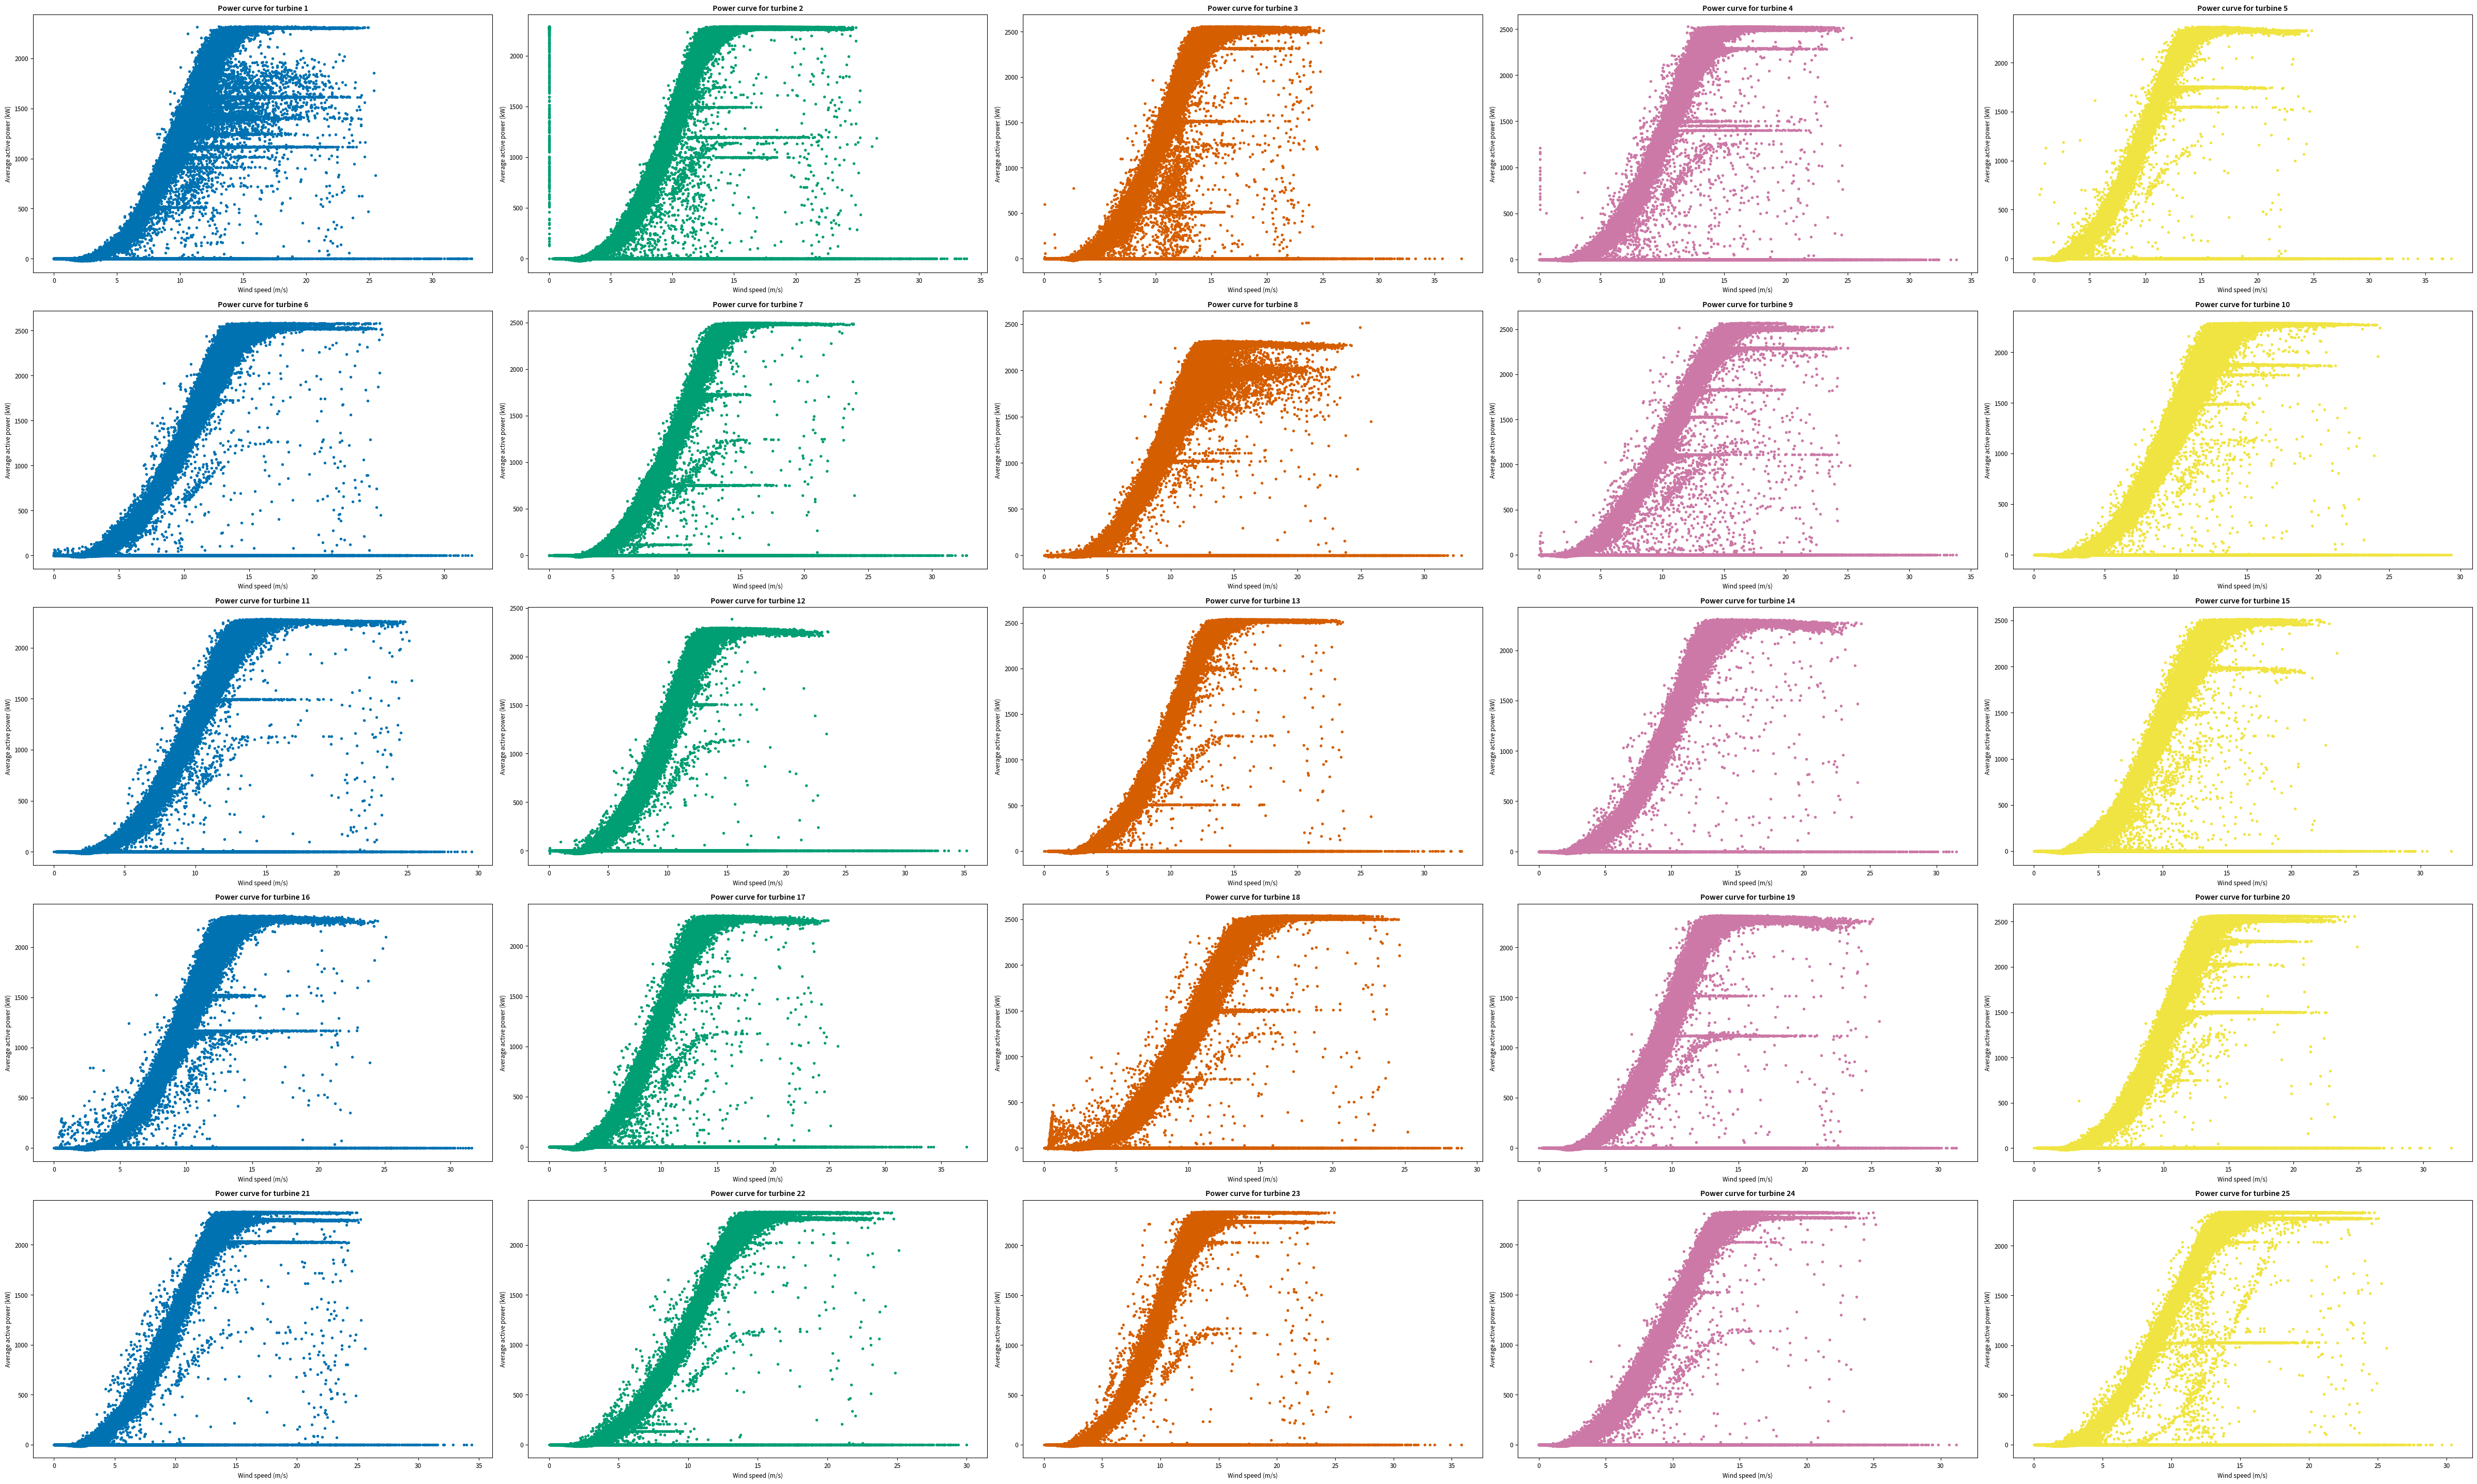

In [9]:
# plotting all columns (i.e. turbines 1 to 25) in the same figure
fig, axs = plt.subplots(ncols=5, nrows=5, figsize=(50, 30))

for (x, y), col in zip(coord, cols):
    axs[x, y].scatter(x=power.index, y=power[col], marker=".", c="C" + str(y))
    axs[x, y].set_title("Power curve for turbine " + str(col))
    axs[x, y].set_xlabel("Wind speed (m/s)")
    axs[x, y].set_ylabel("Average active power (kW)")

fig.tight_layout()
plt.show()

## Normalised power curves

In [10]:
# normalise using feature scaling (all values in the range [0, 1])
power_norm = (power - power.min()) / (power.max() - power.min())
power_norm.index = (power.index - power.index.min()) / (
    power.index.max() - power.index.min()
)

In [11]:
# rename index
power_norm.index.name = "Wind speed"

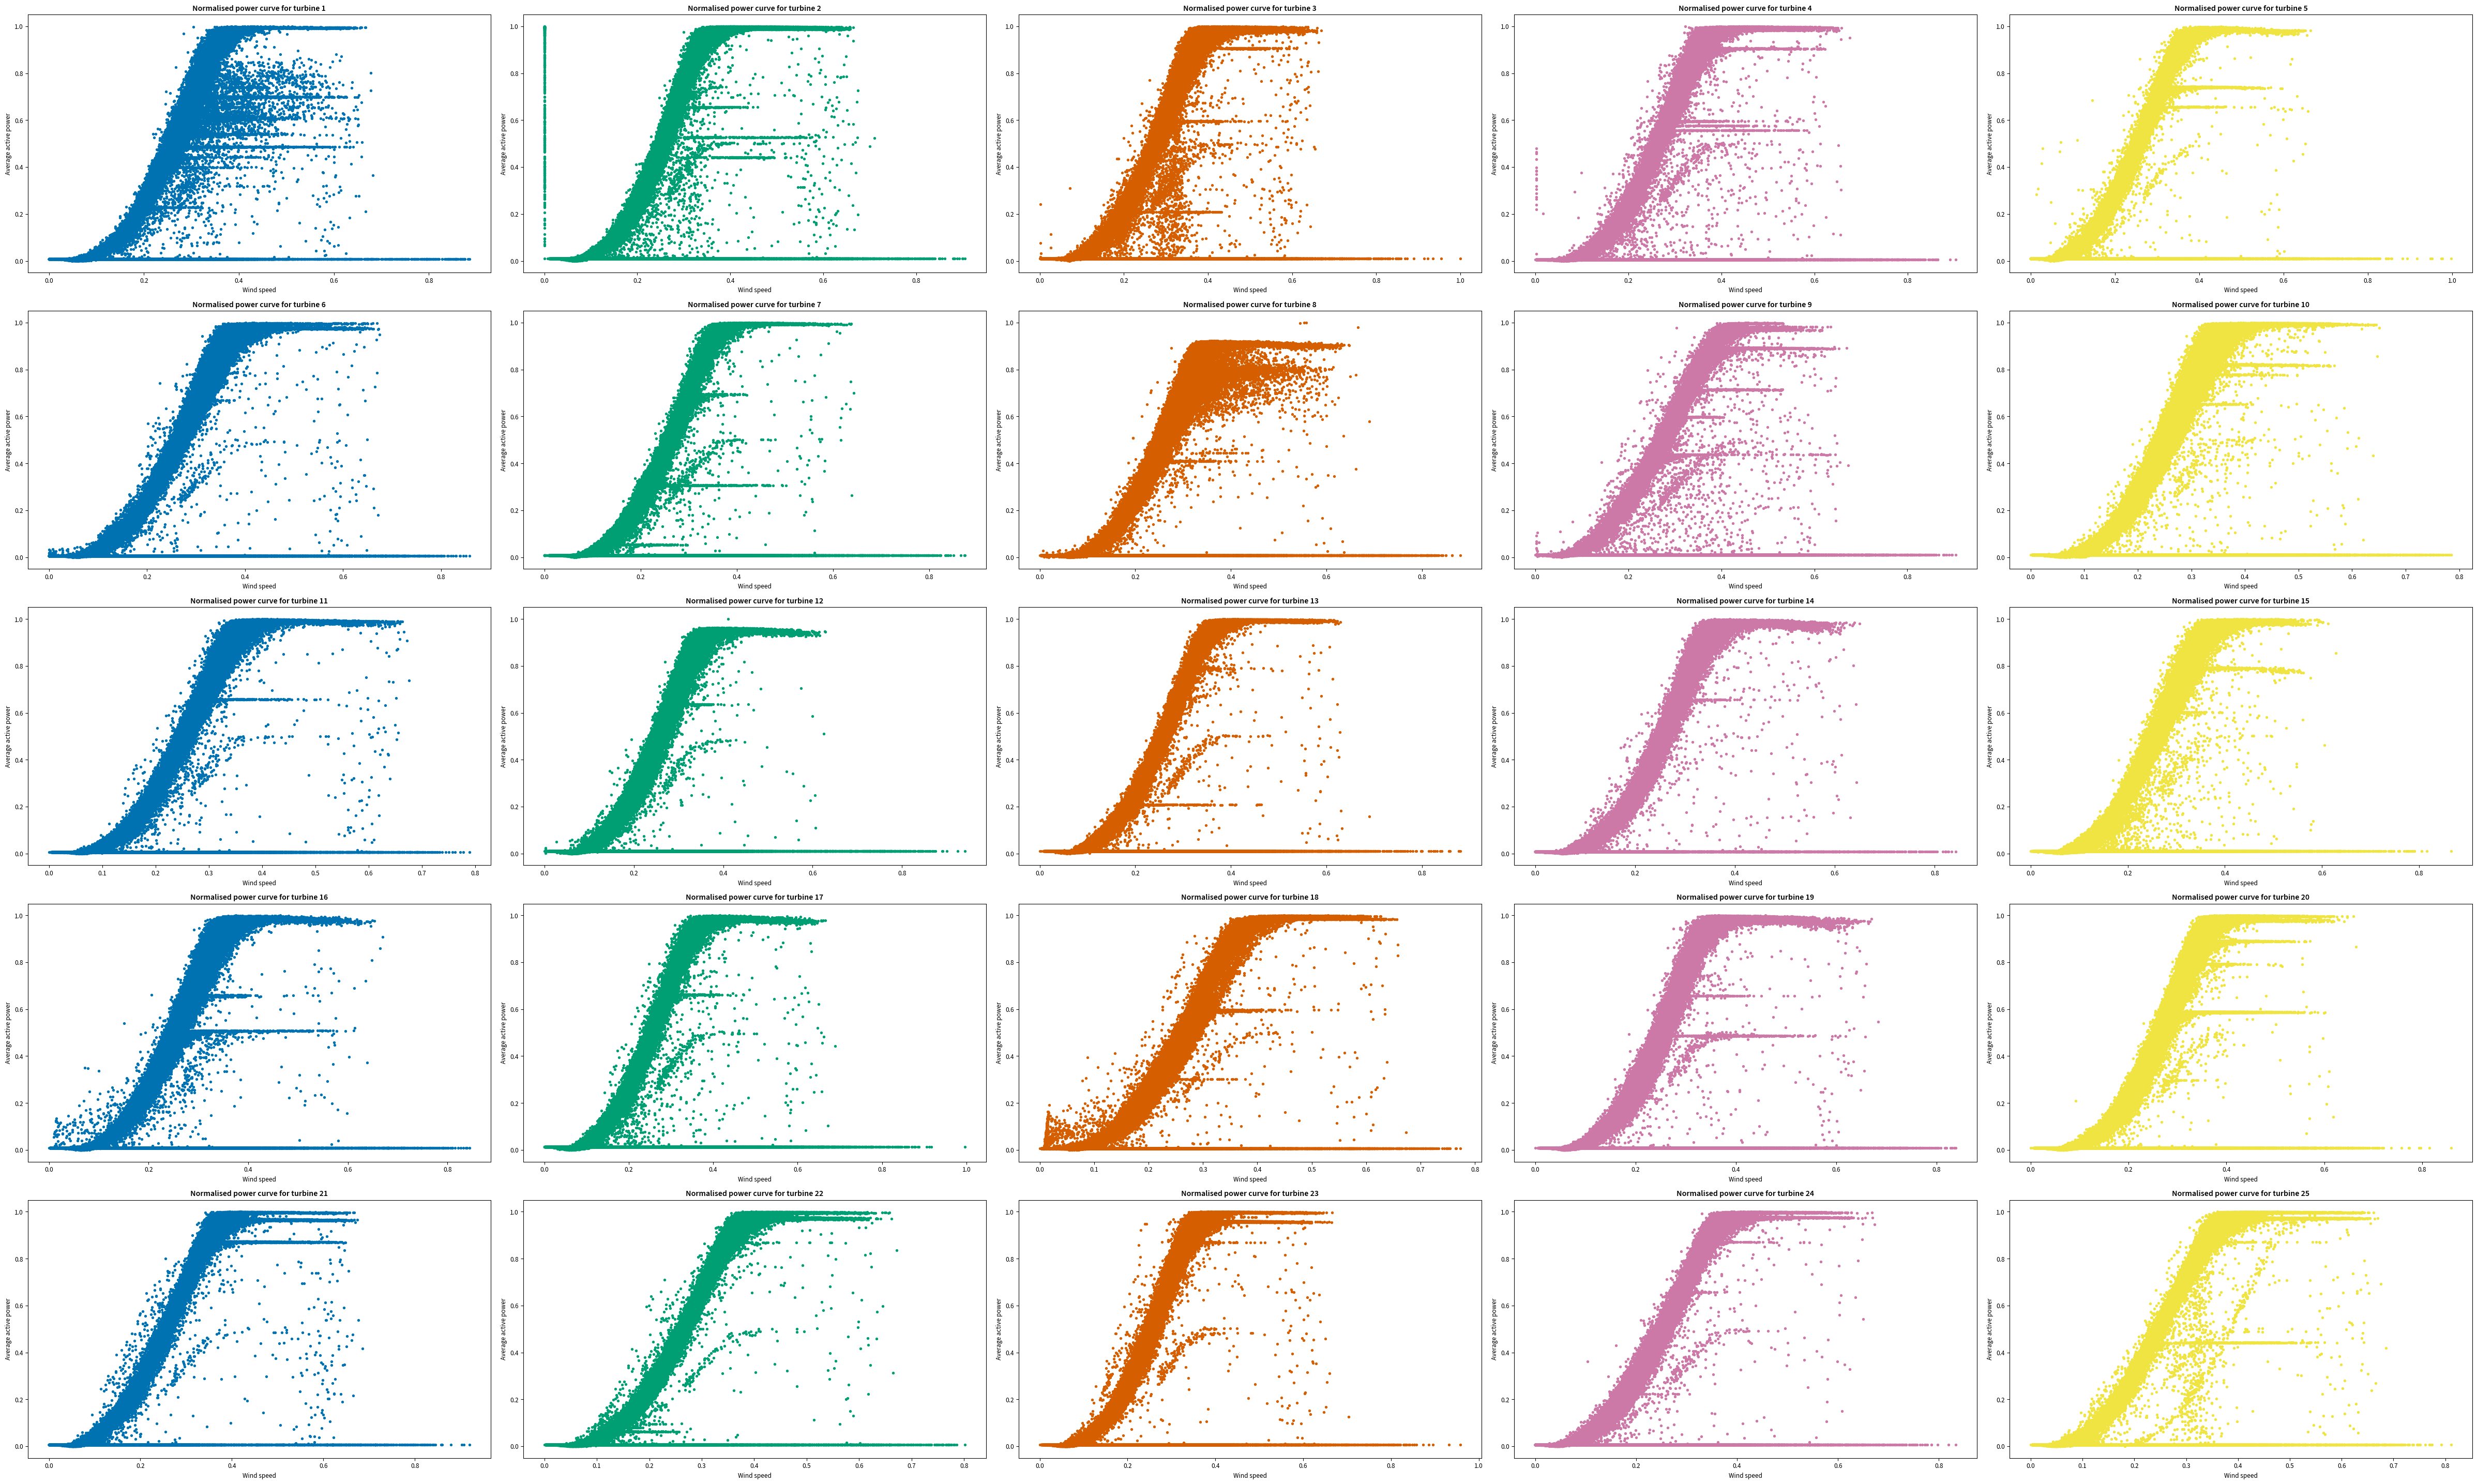

In [12]:
fig, axs = plt.subplots(ncols=5, nrows=5, figsize=(50, 30))

for (x, y), col in zip(coord, cols):
    axs[x, y].scatter(
        x=power_norm.index, y=power_norm[col], marker=".", c="C" + str(y)
    )
    axs[x, y].set_title("Normalised power curve for turbine " + str(col))
    axs[x, y].set_xlabel("Wind speed")
    axs[x, y].set_ylabel("Average active power")

fig.tight_layout()
plt.show()

## Rotor speed vs power

In [5]:
# create pivot table (new dataframe)
power = pd.pivot_table(
    data, index=["rs_av"], columns=["turbine"], values=["ap_av"]
)

In [6]:
# removing pivot table values name from heading
power.columns = power.columns.droplevel(0)

In [7]:
# rename index
power.index.name = "Rotor speed (rpm)"

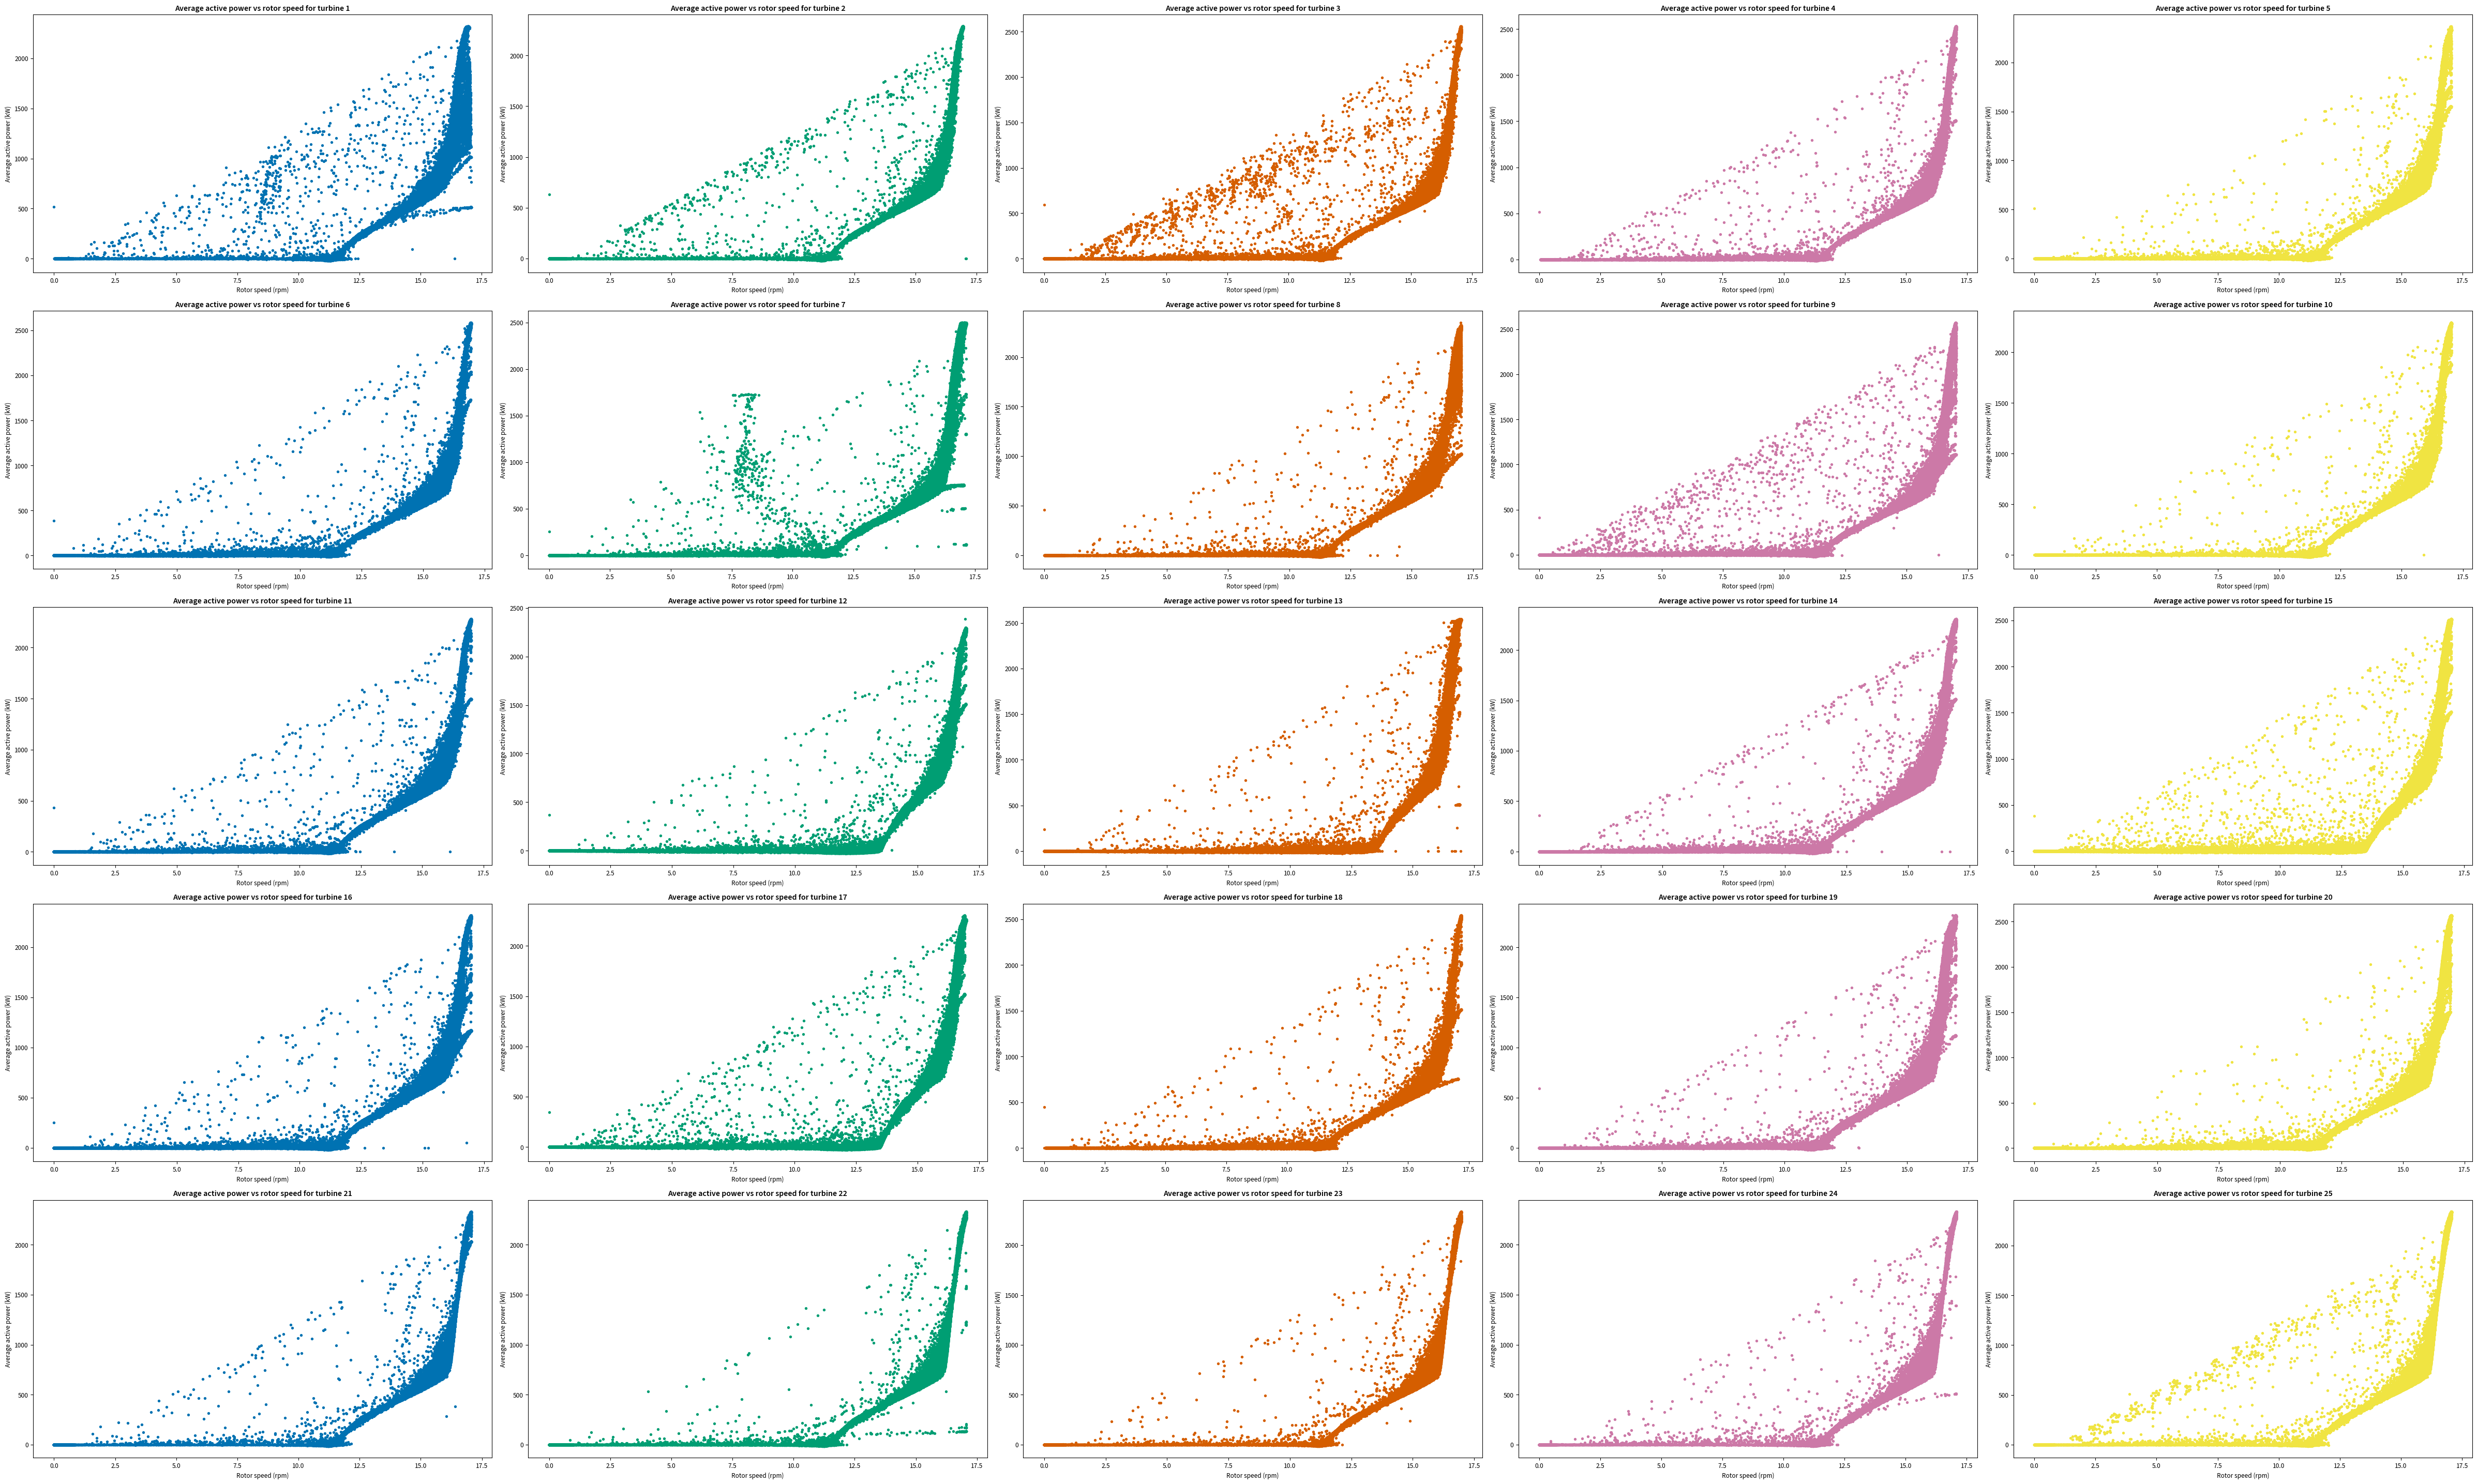

In [10]:
# plotting all columns (i.e. turbines 1 to 25) in the same figure
fig, axs = plt.subplots(ncols=5, nrows=5, figsize=(50, 30))

for (x, y), col in zip(coord, cols):
    axs[x, y].scatter(x=power.index, y=power[col], marker=".", c="C" + str(y))
    axs[x, y].set_title(
        "Average active power vs rotor speed for turbine " + str(col)
    )
    axs[x, y].set_xlabel("Rotor speed (rpm)")
    axs[x, y].set_ylabel("Average active power (kW)")

fig.tight_layout()
plt.show()

## Power vs pitch angle

In [11]:
# create pivot table (new dataframe)
power = pd.pivot_table(
    data, index=["ap_av"], columns=["turbine"], values=["pitch"]
)

In [12]:
# removing pivot table values name from heading
power.columns = power.columns.droplevel(0)

In [13]:
# rename index
power.index.name = "Average active power (kW)"

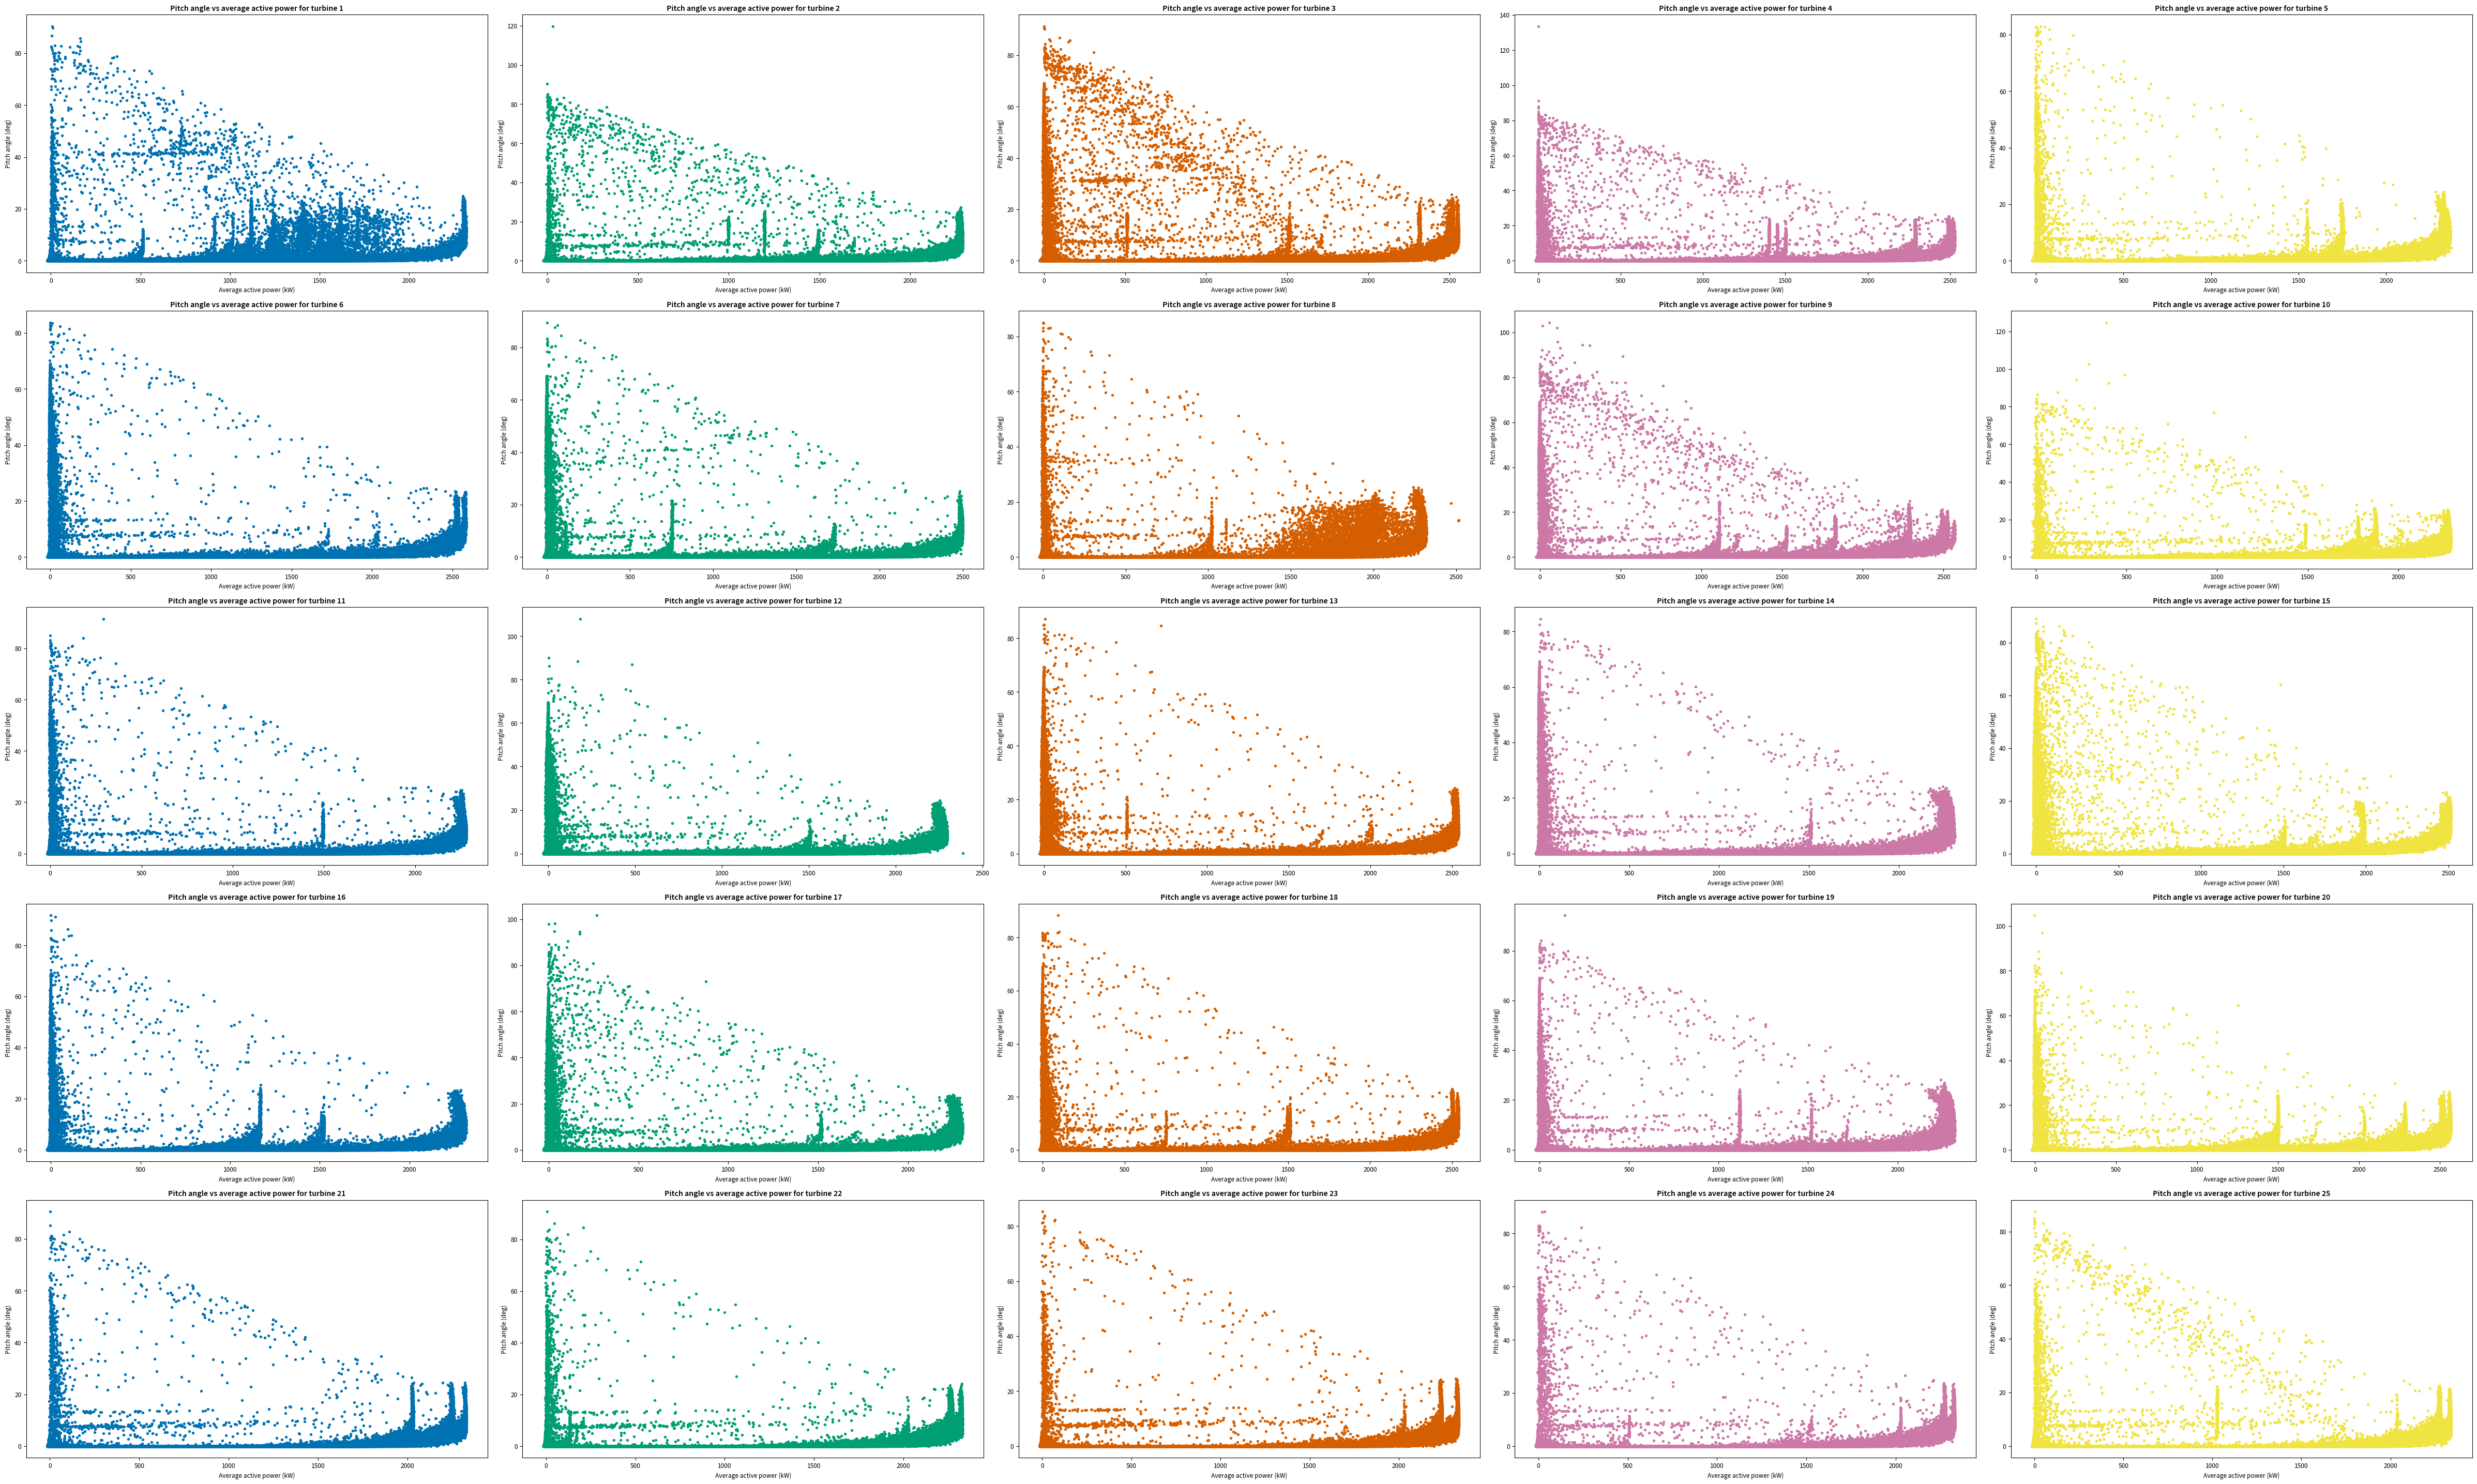

In [14]:
# plotting all columns (i.e. turbines 1 to 25) in the same figure
fig, axs = plt.subplots(ncols=5, nrows=5, figsize=(50, 30))

for (x, y), col in zip(coord, cols):
    axs[x, y].scatter(x=power.index, y=power[col], marker=".", c="C" + str(y))
    axs[x, y].set_title(
        "Pitch angle vs average active power for turbine " + str(col)
    )
    axs[x, y].set_xlabel("Average active power (kW)")
    axs[x, y].set_ylabel("Pitch angle (deg)")

fig.tight_layout()
plt.show()